In [1]:
HOLDING_PENALTY = 0.0
BATCH_SIZE = 128
WARMUP = 500
EPS_DECAY = 0.98
TICKER = "2330.TW"
EPISODES = 100

In [2]:
import numpy as np


class TradingEnv:
    """
    action:
        0 (hold)
        1 (open long)
        2 (open short)
        3 (close)
        4 (tighten stop)
    position: 0 (flat), 1 (long), -1 (short)
    reward: change in equity
    """

    def __init__(
        self,
        prices: np.ndarray,
        window_size: int = 20,
        fee_rate: float = 0.0005,
        slippage_rate: float = 0.0005,
        init_cash: float = 100_000.0,
        stop_atr_mult: float = 2.0,
        penalty_vol_scale: float = 20.0,
    ) -> None:
        self.prices = prices.astype(np.float32)
        self.window_size = window_size
        self.fee_rate = fee_rate
        self.slippage_rate = slippage_rate
        self.init_cash = init_cash
        self.stop_atr_mult = stop_atr_mult
        self.penalty_vol_scale = penalty_vol_scale

        self.action_size = 5
        self.state_size = window_size + 6

        self.reset()

    def reset(self) -> np.ndarray:
        self.t = self.window_size
        self.cash = self.init_cash
        self.equity = self.init_cash
        self.prev_equity = self.init_cash

        self.position = 0
        self.entry_price = 0.0
        self.position_size = 1
        self.holding_steps = 0
        self.stop_price = 0.0

        self.done = False

        return self._get_state()

    # ----- utility methods ----- #
    def _unrealized_pnl(self, price: float) -> float:
        return (price - self.entry_price) * self.position * self.position_size

    def _calc_atr_like(self, t: int, lookback: int = 14) -> float:
        start = max(0, t - lookback)
        diffs = np.abs(np.diff(self.prices[start : t + 1]))
        return float(np.mean(diffs))

    def _penalty_multiplier(self, price: float) -> float:
        atr = self._calc_atr_like(self.t)
        vol_ratio = atr / price
        return 1.0 + (self.penalty_vol_scale * vol_ratio)

    def _apply_cost(self, trade_notional: float) -> None:
        cost = trade_notional * (self.fee_rate + self.slippage_rate)
        self.cash -= cost

    def _check_stop_hit(self, price: float) -> bool:
        if self.position == 1 and price <= self.stop_price:
            return True
        elif self.position == -1 and price >= self.stop_price:
            return True
        return False

    def _mark_to_market(self, price: float) -> None:
        self.equity = self.cash + self._unrealized_pnl(price)

    # ----- action methods ----- #
    def _open_position(self, side: int, price: float) -> None:
        # side: 1 (long), -1 (short)
        self.position = side
        self.entry_price = price
        self.holding_steps = 0

        atr = self._calc_atr_like(self.t)
        if side == 1:
            self.stop_price = price - self.stop_atr_mult * atr
        else:
            self.stop_price = price + self.stop_atr_mult * atr

        self._apply_cost(price * self.position_size)

    def _close_position(self, price: float) -> None:
        pnl = (price - self.entry_price) * self.position * self.position_size
        self.cash += pnl
        self._apply_cost(price * self.position_size)

        self.position = 0
        self.entry_price = 0.0
        self.holding_steps = 0
        self.stop_price = 0.0

    def _tighten_stop(self, price: float) -> None:
        if self.position == 1:
            atr = self._calc_atr_like(self.t)
            new_stop = price - atr
            self.stop_price = max(self.stop_price, new_stop)
        elif self.position == -1:
            atr = self._calc_atr_like(self.t)
            new_stop = price + atr
            self.stop_price = min(self.stop_price, new_stop)

    # ----- core RL methods ----- #
    def _get_state(self) -> np.ndarray:
        window_prices = self.prices[self.t - self.window_size : self.t + 1]
        returns = np.diff(window_prices) / window_prices[:-1]  # return rate (20 states)

        price = self.prices[self.t]
        unrealized_pnl = self._unrealized_pnl(price)
        stop_dist = 0.0
        if self.position != 0:
            stop_dist = (price - self.stop_price) * self.position

        extra = np.array(
            [
                float((self.equity - self.init_cash) / self.init_cash),  # equity change
                float(self.position),  # position
                float(self.holding_steps / 100.0),  # holding steps (normalized)
                float(unrealized_pnl / self.init_cash),  # unrealized PnL (normalized)
                float(stop_dist / price),  # stop distance (normalized)
                float(self._calc_atr_like(self.t) / price),  # ATR-like volatility
            ],
            dtype=np.float32,
        )

        state = np.concatenate([returns.astype(np.float32), extra])
        return state

    def get_valid_actions(self) -> list[int]:
        if self.position == 0:
            return [0, 1, 2]  # hold, open long, open short
        return [0, 3, 4]  # hold, close, tighten stop

    def step(self, action: int) -> tuple[np.ndarray, float, bool, dict]:
        if self.done:
            return self._get_state(), 0.0, True, {}

        price = self.prices[self.t]
        penalty_mult = self._penalty_multiplier(price)

        invalid_penalty = 0.0
        if action == 1:  # open long
            if self.position == 0:
                self._open_position(1, price)
            else:
                invalid_penalty = 1.0 * penalty_mult
        elif action == 2:  # open short
            if self.position == 0:
                self._open_position(-1, price)
            else:
                invalid_penalty = 1.0 * penalty_mult
        elif action == 3:  # close
            if self.position != 0:
                self._close_position(price)
            else:
                invalid_penalty = 0.5 * penalty_mult
        elif action == 4:  # tighten stop
            if self.position != 0:
                self._tighten_stop(price)
            else:
                invalid_penalty = 0.2 * penalty_mult

        self.t += 1
        if self.t >= len(self.prices) - 1:
            self.done = True

        next_price = float(self.prices[self.t])

        if self.position != 0 and self._check_stop_hit(next_price):
            self._close_position(next_price)

        if self.position != 0:
            self.holding_steps += 1

        self.prev_equity = self.equity
        self._mark_to_market(next_price)

        reward = (self.equity - self.prev_equity) - invalid_penalty

        holding_penalty = 0.0
        if (
            self.position != 0
        ):  # holding penalty scaled by volatility (prevent infinite holding)
            holding_penalty = HOLDING_PENALTY * penalty_mult
            reward -= holding_penalty

        next_state = self._get_state()
        info = {
            "equity": self.equity,
            "invalid_penalty": invalid_penalty,
            "holding_penalty": holding_penalty,
        }
        return next_state, float(reward), self.done, info

In [3]:
from collections import deque
from dataclasses import dataclass
import random
from typing import Deque


@dataclass
class Transition:
    s: np.ndarray  # state
    a: int  # action
    r: float  # reward
    ns: np.ndarray  # next state
    d: bool  # done


class ReplayBuffer:
    def __init__(self, capacity: int = 100_000) -> None:
        self.buffer: Deque[Transition] = deque(maxlen=capacity)

    def push(self, *args) -> None:
        self.buffer.append(Transition(*args))

    def sample(
        self, batch_size: int
    ) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        batch = random.sample(self.buffer, batch_size)
        s = np.array([b.s for b in batch], dtype=np.float32)
        a = np.array([b.a for b in batch], dtype=np.int64)
        r = np.array([b.r for b in batch], dtype=np.float32)
        ns = np.array([b.ns for b in batch], dtype=np.float32)
        d = np.array([b.d for b in batch], dtype=np.float32)
        return s, a, r, ns, d

    def __len__(self) -> int:
        return len(self.buffer)

In [4]:
import torch.nn as nn


class QNet(nn.Module):
    def __init__(self, state_dim: int, action_dim: int) -> None:
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim),
        )

    def forward(self, x) -> nn.Sequential:
        return self.net(x)

In [5]:
import torch
import torch.optim as optim


def train_dqn(prices: np.ndarray, episodes: int = 20) -> tuple[QNet, list[float]]:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    env = TradingEnv(prices, window_size=20)
    q = QNet(env.state_size, env.action_size).to(device)
    q_target = QNet(env.state_size, env.action_size).to(device)
    q_target.load_state_dict(q.state_dict())

    optimizer = optim.Adam(q.parameters())
    rb = ReplayBuffer(capacity=50_000)

    gamma = 0.99
    batch_size = BATCH_SIZE
    warmup = WARMUP
    train_freq = 4
    target_update_freq = 500

    eps_start, eps_end, eps_decay = 1.0, 0.05, EPS_DECAY
    epsilon = eps_start

    global_step = 0

    def masked_argmax(q_values: torch.Tensor, valid_actions: list[int]) -> int:
        mask = torch.full_like(q_values, -1e9)
        mask[valid_actions] = 0.0
        return int(torch.argmax(q_values + mask).item())

    ep_rewards = []
    for ep in range(1, episodes + 1):
        s = env.reset()
        ep_reward = 0.0
        ep_invalid_penalty = 0.0
        ep_holding_penalty = 0.0

        while True:
            global_step += 1
            valid_actions = env.get_valid_actions()

            if random.random() < epsilon:
                a = random.choice(valid_actions)
            else:
                with torch.no_grad():
                    qs = q(
                        torch.tensor(s, dtype=torch.float32, device=device).unsqueeze(0)
                    ).squeeze(0)
                    a = masked_argmax(qs, valid_actions)

            ns, r, d, info = env.step(a)
            rb.push(s, a, r, ns, d)
            s = ns
            ep_reward += r
            ep_invalid_penalty += info["invalid_penalty"]
            ep_holding_penalty += info["holding_penalty"]

            if len(rb) >= warmup and global_step % train_freq == 0:
                bs, ba, br, bns, bd = rb.sample(batch_size)

                bs_t = torch.tensor(bs, dtype=torch.float32, device=device)
                ba_t = torch.tensor(ba, dtype=torch.long, device=device).unsqueeze(1)
                br_t = torch.tensor(br, dtype=torch.float32, device=device).unsqueeze(1)
                bns_t = torch.tensor(bns, dtype=torch.float32, device=device)
                bd_t = torch.tensor(bd, dtype=torch.float32, device=device).unsqueeze(1)

                q_values = q(bs_t).gather(1, ba_t)

                with torch.no_grad():
                    pos_idx = env.window_size + 1
                    next_pos = bns_t[:, pos_idx]
                    is_flat = torch.abs(next_pos) < 0.5  # prevent floating point issues

                    valid_mask = torch.zeros(
                        (batch_size, env.action_size), dtype=torch.bool, device=device
                    )
                    valid_mask[:, 0] = True
                    valid_mask[is_flat, 1] = True
                    valid_mask[is_flat, 2] = True
                    valid_mask[~is_flat, 3] = True
                    valid_mask[~is_flat, 4] = True

                    next_q_online = q(bns_t).masked_fill(~valid_mask, -1e9)
                    next_actions = torch.argmax(next_q_online, dim=1, keepdim=True)

                    next_q_target = q_target(bns_t).masked_fill(~valid_mask, -1e9)
                    next_q = next_q_target.gather(1, next_actions)

                    target = br_t + gamma * (1.0 - bd_t) * next_q

                loss = nn.functional.smooth_l1_loss(q_values, target)

                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(q.parameters(), 5.0)
                optimizer.step()

            if global_step % target_update_freq == 0:
                q_target.load_state_dict(q.state_dict())

            if d:
                break

        ep_rewards.append(ep_reward)
        print(
            f"[Episode {ep:03d}] Equity: {info['equity']:9.2f} | Reward={ep_reward:9.2f} (Invalid={ep_invalid_penalty:4.2f}, Holding={ep_holding_penalty:4.2f}) | Epsilon={epsilon:4.3f}"
        )
        epsilon = max(eps_end, epsilon * eps_decay)

    return q, ep_rewards

In [6]:
import matplotlib.pyplot as plt


def plot_results(losses, rewards):
    _, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].plot(losses)
    axes[0].set_title("DQN Loss")

    axes[1].plot(rewards)
    axes[1].set_title("Episode Rewards")

    plt.tight_layout()
    plt.show()

[*********************100%***********************]  1 of 1 completed


(1456, 5)
[Episode 001] Equity:  99194.73 | Reward=  -805.27 (Invalid=0.00, Holding=0.00) | Epsilon=1.000
[Episode 002] Equity:  99001.84 | Reward=  -998.16 (Invalid=0.00, Holding=0.00) | Epsilon=0.980
[Episode 003] Equity:  99848.16 | Reward=  -151.84 (Invalid=0.00, Holding=0.00) | Epsilon=0.960
[Episode 004] Equity:  99150.98 | Reward=  -849.02 (Invalid=0.00, Holding=0.00) | Epsilon=0.941
[Episode 005] Equity:  99827.48 | Reward=  -172.52 (Invalid=0.00, Holding=0.00) | Epsilon=0.922
[Episode 006] Equity:  99094.68 | Reward=  -905.32 (Invalid=0.00, Holding=0.00) | Epsilon=0.904
[Episode 007] Equity:  99802.57 | Reward=  -197.43 (Invalid=0.00, Holding=0.00) | Epsilon=0.886
[Episode 008] Equity:  99501.80 | Reward=  -498.20 (Invalid=0.00, Holding=0.00) | Epsilon=0.868
[Episode 009] Equity:  99707.82 | Reward=  -292.18 (Invalid=0.00, Holding=0.00) | Epsilon=0.851
[Episode 010] Equity:  99324.23 | Reward=  -675.77 (Invalid=0.00, Holding=0.00) | Epsilon=0.834
[Episode 011] Equity: 100411.7

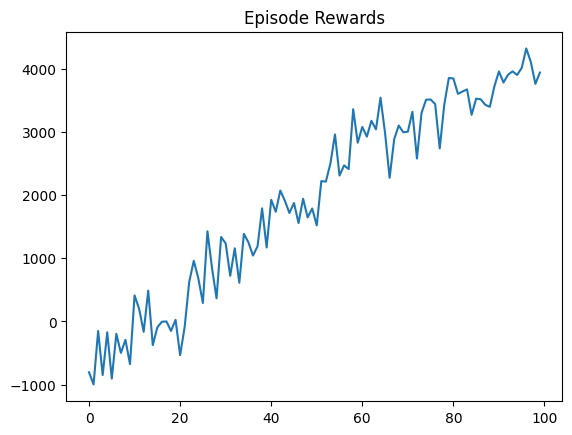

In [7]:
import yfinance as yf
import matplotlib.pyplot as plt

df = yf.download(TICKER, start="2020-01-01", end="2025-12-31")
if df is None or df.empty:
    raise ValueError("Failed to download train data")

df.columns = df.columns.droplevel(1)
print(df.shape)

model, rewards = train_dqn(df["Close"].to_numpy(), EPISODES)
print("Training completed")

plt.plot(rewards)
plt.title("Episode Rewards")
plt.show()